In [44]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path
from typing import Any, NamedTuple

import numpy as np  # type: ignore[import-not-found]
import torch
from ax import SearchSpace
from ax.core import RangeParameter
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood
from matplotlib import pyplot as plt
from scipy import stats

torch.set_default_dtype(torch.float64)

# Add notebook directory to sys.path so local modules (e.g. problem.py) can be imported.
_examples_dir = Path.cwd()
if str(_examples_dir) not in sys.path:
    sys.path.insert(0, str(_examples_dir))

from problem import SEARCH_SPACE, make_exp  # type: ignore[import-not-found]  # noqa: E402


### Extracting Training Data as Tensors

We could have called model.train_inputs to get the Ax DataFrame directly, but **Ax applies internal transforms** so train_inputs is already normalised and standardised across all points.

We do not want that, normalising/standardising based on all-points statistics leaks information about the held-out point. For proper LOO cross-validation, each fold must compute its own normalisation and standardisation statistics from the n−1 training points only.

The function below reads the Ax experiment's DataFrame and assembles (X, Y, Yvar) in the original problem space (untransformed).


### Observation Noise Variance (Yvar)

Yvar is the observation noise variance derived from the Gumbel MLE estimate:
$$\text{sem} = \sqrt{\text{Var}[\hat{\theta}_\text{MLE}]} \quad \Rightarrow \quad Y_\text{var} = \text{sem}^2$$

This captures the aleatoric (label) noise/finite-sample estimation error from a limited number of simulator draws per point (e.g., 100).

### Ax DataFrame Structure

Ax links input parameters to output metrics via arms:

experiment.trials
└── Trial (index 0)
    └── Arm "0_0"
        ├── arm.parameters = {"Hs": 4.2, "Tp": 8.7}   →  X
        └── trial.run_metadata["simulation_result"]
                → LocalMetadataMetric reads it
                → df row:  arm_name="0_0",  metric_name="loc"
                           mean=12.3,  sem=0.4    # mean → Y,  sem² → Yvar

In [45]:
def extract_training_tensors(  # noqa: C901
    experiment: Any, # noqa: ANN401
    metric_names: list[str],
    parameter_names: list[str],
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Extract training data from an Ax experiment into tensors.

    Args:
        experiment: The finished Ax Experiment.
        metric_names: Ordered list of output metric names, e.g. ["loc", "scale"].
        parameter_names: Ordered list of input parameter names, e.g. ["Hs", "Tp"].

    Returns:
        X:    (n, d)  input locations in problem space.
        Y:    (n, m)  output means (GP training targets, in problem space).
        Yvar: (n, m)  output variance = sem^2 (aleatoric/observation noise, heteroscedastic).

    """
    # Collects results from completed trials as (arm_name, metric_name, mean, sem) rows.
    df = experiment.fetch_data().df
    print(f"Extracted raw data frame with {len(df)} rows from Ax experiment.")
    print(f"Available metrics: {df['metric_name'].unique()}")
    print(f"A row example: {df}")

    df = df[df["metric_name"].isin(metric_names)].copy()

    # Build a parameter lookup: arm_name -> parameter dict.
    arm_params: dict[str, dict] = {}
    for trial in experiment.trials.values():
        for arm in trial.arms:
            arm_params[arm.name] = arm.parameters

    arm_names_ordered: list[str] = []
    seen: set[str] = set()
    for trial in sorted(experiment.trials.values(), key=lambda t: t.index):
        for arm in trial.arms:
            if arm.name not in seen:
                arm_names_ordered.append(arm.name)
                seen.add(arm.name)

    xs, ys, yvars = [], [], []
    for arm_name in arm_names_ordered:
        arm_df = df[df["arm_name"] == arm_name]
        if arm_df.empty:
            continue

        params = arm_params[arm_name]
        x = [params[p] for p in parameter_names]

        y_row, yvar_row = [], []
        for mn in metric_names:
            row = arm_df[arm_df["metric_name"] == mn]
            if row.empty:
                continue
            mean_val = float(row["mean"].values[0])  # Gumbel MLE
            sem_val = float(row["sem"].values[0])  # sqrt of Fisher covariance
            y_row.append(mean_val)
            yvar_row.append(sem_val**2)  # variance = sem², the aleatoric/observation noise

        if len(y_row) == len(metric_names):
            xs.append(x)
            ys.append(y_row)
            yvars.append(yvar_row)

    X = torch.tensor(xs, dtype=torch.float64)  # (n, d)  # noqa: N806
    Y = torch.tensor(ys, dtype=torch.float64)  # (n, m)  # noqa: N806
    Yvar = torch.tensor(yvars, dtype=torch.float64)  # (n, m)  # noqa: N806

    return X, Y, Yvar


def make_bounds_tensor(search_space: SearchSpace, parameter_names: list[str]) -> torch.Tensor:
    """Return (2, d) bounds tensor [[lower, ...], [upper, ...]] from an Ax SearchSpace.

    This is used to build the Normalize input transform, matching Ax's UnitX transform.
    """
    lowers, uppers = [], []
    for name in parameter_names:
        p = search_space.parameters[name]
        assert isinstance(p, RangeParameter), f"Only RangeParameters supported, got {type(p)}"
        lowers.append(p.lower)
        uppers.append(p.upper)

    return torch.tensor([lowers, uppers], dtype=torch.float64)  # (2, d)


### Building the GP : Applied Transforms

Since we imported untransformed tensors, we manually apply the same transforms that Ax/BoTorch uses internally when fitting the GP:

| Transform | Does |
|-----------|---------|
| NormalizeX | Normalises input X to $[0, 1]$ using the search space bounds |
| StandardizeY | Standardises each output metric to zero mean and unit std,built into SingleTaskGP by default |
| Kernel | Matérn 5/2 (BoTorch default) |


### Assumption: Fixed Observation Noise

Since train_Yvar is provided, BoTorch uses [FixedNoiseGaussianLikelihood](see here : https://botorch.readthedocs.io/en/v0.15.1/_modules/botorch/models/gp_regression.html). The sem² values in train_Yvar are treated as ground-truth observation noise, i.e., they are not learnt or adjusted during hyperparameter optimisation.

In [46]:
def build_gp(
    train_X: torch.Tensor,  # noqa: N803
    train_Y: torch.Tensor,  # noqa: N803
    train_Yvar: torch.Tensor,  # noqa: N803
    bounds: torch.Tensor,
    *,
    fit: bool = True,
) -> SingleTaskGP:
    """Build and fit a SingleTaskGP on the given training data.

    Args:
        train_X: (n, d) tensor of input locations in problem space.
        train_Y: (n, m) tensor of output values in problem space.
        train_Yvar: (n, m) tensor of output variances in problem space.
        bounds: (2, d) tensor of input bounds.
        fit: Whether to fit the GP. Set False to skip fitting (e.g. for debugging).

    Returns:
        A fitted (or unfitted if fit=False) SingleTaskGP model.

    """
    d = train_X.shape[-1]
    input_transform = Normalize(d=d, bounds=bounds)

    model = SingleTaskGP(
        train_X=train_X,
        train_Y=train_Y,
        train_Yvar=train_Yvar,
        input_transform=input_transform,
        # StandardizeY is applied by default inside SingleTaskGP.
    )

    if fit:
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit_gpytorch_mll(mll)  # L-BFGS-B; maximises the marginal log-likelihood

    model.eval()
    return model


class LOOFoldResult(NamedTuple):
    """Result of one Leave-One-Out fold, with one point left out."""

    idx: int  # index of the left-out point
    x_left_out: torch.Tensor  # (d,) left-out input location in problem space
    y_left_out: torch.Tensor  # (m,) left-out output value (mean) in problem space
    yvar_left_out: torch.Tensor  # (m,) left-out output variance (sem²) in problem space
    y_pred_mean: torch.Tensor  # (m,) predicted mean at left-out point (GP on n-1 points)
    y_pred_var_epistemic: torch.Tensor  # (m,) GP epistemic variance only (no observation noise)
    pred_var_total: torch.Tensor  # (m,) total predictive variance = epistemic + aleatoric


### Running the Leave-One-Out Validation Loop

For each point $i$ in the training data:

1. Build the GP on $(X_{-i},\, Y_{-i},\, Y_\text{var,-i})$, all points except $i$.
2. Fit kernel hyperparameters (Matérn length-scale and output scale) via MLL on these $n-1$ points.
3. Compute the **epistemic posterior** at point $i$ (observation_noise=False) : uncertainty due to lack of data.
4. Compute the **total predictive posterior** at point $i$ (observation_noise=True) : epistemic + aleatoric uncertainty.

#### Why both Step 3 and Step 4?

- **Step 3** isolates the epistemic uncertainty at the held-out point, which reflects the GP's ability to generalise to unseen locations. This is the primary signal for LOO evaluation.
- **Step 4** additionally accounts for aleatoric uncertainty (observation noise). Near a training point the epistemic variance would be close to zero, but if the observation noise is high (e.g. because only a small number of simulations were used to fit the Gumbel parameters), that uncertainty still matters and should be included in the predictive distribution.
- Together, Step 4 answers: *"Is the GP uncertain because the observation itself is noisy?"*

#### Important Note: 
How does observation_noise=True work for an unseen point?
Sample noise is a property of the input data only, so how does the model estimate aleatoric uncertainty for a held-out point it has never seen?

- When SingleTaskGP is initialised with train_Yvar, BoTorch uses a FixedNoiseGaussianLikelihood. For an unseen test point, it simply returns mean(Yvar): the mean of the training noise values rather than a point-specific estimate. (See botorch/models/gpytorch.py, line 408.)
- The BoTorch developers note this is a simplification. The underlying assumption is that label noise does not vary dramatically across input space. This is not a severe limitation, but worth being aware of: our noise is heteroscedastic, and without additional assumptions there is no better way to estimate it at an unseen location.
- As the number of simulator runs per point increases, the observation noise Yvar decreases and becomes better controlled.
- Consequence for this script: yvar_left_out is the exact (ground-truth) noise at the held-out point, whereas pred_var_total − pred_var_epistemic is BoTorch's estimate i.e., the mean of the $n-1$ remaining training noise values.

In [47]:
def run_loo(
    X: torch.Tensor,  # noqa: N803
    Y: torch.Tensor,  # noqa: N803
    Yvar: torch.Tensor,  # noqa: N803
    bounds: torch.Tensor,
    indices: list[int] | None = None,
    *,
    verbose: bool = True,
) -> list[LOOFoldResult]:
    """Run Leave-One-Out cross validation on the given training data.

    Args:
        X: (n, d) tensor of input locations in problem space.
        Y: (n, m) tensor of output values in problem space.
        Yvar: (n, m) tensor of output variances in problem space.
        bounds: (2, d) tensor of input bounds for building the GP.
        indices: Optional list of indices to run LOO on. If None, runs on all points.
        verbose: Print info per fold.

    Returns:
        A list of LOOFoldResult, one for each fold.
    """
    n = X.shape[0]
    if indices is None:
        indices = list(range(n))

    results: list[LOOFoldResult] = []

    for fold, i in enumerate(indices):
        if verbose:
            print(f"\nRunning LOO fold {fold + 1}/{len(indices)}: leaving out point index {i}...")

        keep = [j for j in range(n) if j != i]
        X_loo = X[keep]  # (n-1, d)  # noqa: N806
        Y_loo = Y[keep]  # (n-1, m)  # noqa: N806
        Yvar_loo = Yvar[keep]  # (n-1, m)  # noqa: N806

        gp_model = build_gp(X_loo, Y_loo, Yvar_loo, bounds, fit=True)

        x_left_out = X[i].unsqueeze(0)  # (1, d)

        with torch.no_grad():
            # Epistemic posterior: uncertainty from not having seen this point.
            posterior_epistemic = gp_model.posterior(x_left_out, observation_noise=False)
            posterior_total = gp_model.posterior(x_left_out, observation_noise=True)

        pred_mean = posterior_total.mean.squeeze(0)  # (m,)
        pred_var_epistemic = posterior_epistemic.variance.squeeze(0)  # (m,)
        pred_var_total = posterior_total.variance.squeeze(0)  # (m,)

        results.append(
            LOOFoldResult(
                idx=i,
                x_left_out=X[i],
                y_left_out=Y[i],
                yvar_left_out=Yvar[i],
                y_pred_mean=pred_mean,
                y_pred_var_epistemic=pred_var_epistemic,
                pred_var_total=pred_var_total,
            )
        )

        if verbose:
            print(f"Fold {fold + 1}/{len(indices)}: Left out point index {i}, x={x_left_out.tolist()}")
            print(f"  True y={Y[i].tolist()}, sem²={Yvar[i].tolist()}")
            print(f"  Predicted mean={pred_mean.tolist()}")
            print(f"  Predicted epistemic var={pred_var_epistemic.tolist()}")
            print(f"  Predicted total var={pred_var_total.tolist()}")
    return results


class LOOMetrics(NamedTuple):
    """Metrics computed from the LOO results."""

    metric_name: str
    n_folds: int

    mae: float  # mean absolute error
    rmse: float  # root mean squared error

    # Uncertainty calibration metrics:
    z_scores: np.ndarray  # type: ignore  # (n,) (y_pred_mean - y_left_out) / sqrt(pred_var_total)
    z_mean: float  # mean of z-scores, should be close to 0
    z_std: float  # std of z-scores, should be close to 1
    ci_95_coverage: float  # fraction inside predicted 95% CI (should be ~0.95)

    frac_aleatoric: float  # mean(aleatoric / pred_var_total) across held-out points


def compute_metrics(loo_results: list[LOOFoldResult], metric_idx: int, metric_name: str) -> LOOMetrics:
    """Compute LOO metrics for a specific output metric (e.g., loc or scale).

    Args:
        loo_results: List of LOOFoldResult per fold.
        metric_idx: Index of the output metric (e.g., 0 for loc, 1 for scale).
        metric_name: Name of the metric.

    Returns:
        LOOMetrics containing the computed metrics.
    """
    y_true = np.array([r.y_left_out[metric_idx].item() for r in loo_results])
    y_pred = np.array([r.y_pred_mean[metric_idx].item() for r in loo_results])
    pred_var_total = np.array([r.pred_var_total[metric_idx].item() for r in loo_results])
    true_var_alea = np.array([r.yvar_left_out[metric_idx].item() for r in loo_results])
    pred_var_epi = np.array([r.y_pred_var_epistemic[metric_idx].item() for r in loo_results])
    pred_var_alea = pred_var_total - pred_var_epi

    # Clamp for numerical stability in z-score computation.
    pred_var_total = np.maximum(pred_var_total, 1e-12)

    residuals = y_pred - y_true
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))

    z_scores = residuals / np.sqrt(pred_var_total)
    z_mean = np.mean(z_scores)
    z_std = np.std(z_scores)
    coverage_95 = np.mean(np.abs(z_scores) <= 1.96)  # noqa: PLR2004

    # Using estimated aleatoric (pred_var_alea) for consistency with what the GP uses internally.
    frac_aleatoric = np.mean(pred_var_alea / pred_var_total)

    return LOOMetrics(
        metric_name=metric_name,
        n_folds=len(loo_results),
        mae=mae,
        rmse=rmse,
        z_scores=z_scores,
        z_mean=z_mean,
        z_std=z_std,
        ci_95_coverage=coverage_95,
        frac_aleatoric=frac_aleatoric,
    )


### Plots

**1. Z-score histogram with standard normal overlay**: overlap indicates good calibration of GP uncertainties.
- Mean close to 0, variance close to 1.
- Tails fatter than normal: occasionally large errors, due to kernel choice or poor fit.
- Too spiky: z-score variance is low, GP variance is too large.

**2. Q-Q plot of z-scores against a standard normal distribution**: shows tails more clearly than the histogram.
- Points approximately on the line $y = x$: uncertainties well calibrated.
- Line shifted or curved, or tails deviating: bias, miscalibrated uncertainties, or outliers.

**3. Predicted vs Actual plot** with error bars showing predictive uncertainty intervals (95% CI).
- Points on the diagonal indicate accurate predictions.
- Error bars show $\sqrt{\text{total\_var}}$ = predictive standard deviation (epistemic + aleatoric).

**4. Per-point epistemic vs aleatoric uncertainty bar plot.**
- At each point, how much of the uncertainty is epistemic (lack of data) vs aleatoric (inherent observation noise).
- Indicates where adding more data would help (high epistemic) vs where label noise needs to be managed (high aleatoric).

In [48]:
def plot_loo_results(  # noqa: PLR0915
    loo_results: list[LOOFoldResult],
    metrics_list: list[LOOMetrics],
    metric_names: list[str],
) -> plt.Figure:
    """Plot LOO cross-validation results for each output metric.

    Args:
        loo_results: List of LOOFoldResult per fold.
        metrics_list: List of LOOMetrics per metric.
        metric_names: List of metric display names.

    Returns:
        A matplotlib Figure containing the plots.
    """
    m = len(metrics_list)
    n_rows = 4

    fig, axes = plt.subplots(n_rows, m, figsize=(6 * m, 4 * n_rows))

    if m == 1:
        axes = axes.reshape(n_rows, 1)

    for col, (loom, display_name) in enumerate(zip(metrics_list, metric_names, strict=True)):
        metric_idx = col
        z_scores = loom.z_scores
        y_true = np.array([r.y_left_out[metric_idx].item() for r in loo_results])
        y_pred = np.array([r.y_pred_mean[metric_idx].item() for r in loo_results])
        pred_var_total = np.array([r.pred_var_total[metric_idx].item() for r in loo_results])
        std_total = np.sqrt(pred_var_total)
        true_var_alea = np.array([r.yvar_left_out[metric_idx].item() for r in loo_results])
        pred_var_epi = np.array([r.y_pred_var_epistemic[metric_idx].item() for r in loo_results])
        pred_var_alea = pred_var_total - pred_var_epi

        # 1. Z-score histogram with standard normal overlay
        ax = axes[0, col]
        ax.hist(z_scores, bins=10, density=True, alpha=0.6, color="g", label="LOO z-scores")
        xr = np.linspace(-5, 5, 100)
        ax.plot(xr, stats.norm.pdf(xr), "r-", lw=2, label="N(0,1) reference")
        ax.axvline(0, color="grey", linestyle="--", lw=1)
        ax.set_xlabel("Z-score")
        ax.set_ylabel("Density")
        ax.set_title(
            f"{display_name}\nZ-score histogram\n"
            f"mean={loom.z_mean:+.3f}, std={loom.z_std:.3f} (ideal: mean=0, std=1)"
        )
        ax.legend()

        # 2. Q-Q plot of z-scores against standard normal
        ax = axes[1, col]
        (osm, osr), (slope, intercept, r) = stats.probplot(z_scores, dist="norm")
        ax.scatter(osm, osr, color="blue", label=f"R={r:.3f}")
        ax.plot(osm, float(slope) * np.array(osm) + float(intercept), "r-", lw=2, label="Fit")
        ax.set_title(f"Q-Q Plot: {display_name}")
        ax.set_xlabel("Normal Quantiles")
        ax.set_ylabel("z-score Quantiles")
        ax.legend()

        # 3. Predicted vs Actual with 95% CI error bars
        ax = axes[2, col]
        ax.errorbar(
            y_true,
            y_pred,
            yerr=1.96 * np.sqrt(pred_var_epi),  # so 1.96 * std_total 95% CI (epistemic + aleatoric) can do yerr=1.96*sqrt(pred_var_epi) for epistemic-only CI
            fmt="o",
            ecolor="lightgray",
            elinewidth=3,
            capsize=0,
            label="LOO prediction +/- 1.96*std_total",
        )
        mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        pad = 0.05 * (mx - mn)
        diag = [mn - pad, mx + pad]
        ax.plot(diag, diag, "r--", lw=2, label="Ideal")
        ax.set_xlabel("True value")
        ax.set_ylabel("GP LOO prediction")
        ax.set_title(f"{display_name}\nPredicted vs Actual\nRMSE={loom.rmse:.4f}, MAE={loom.mae:.4f}")
        ax.legend(fontsize=8)

        # 4. Per-point epistemic vs aleatoric uncertainty bar plot
        ax = axes[3, col]
        x = np.arange(len(loo_results))
        ax.bar(x, pred_var_epi, label="Epistemic Var", alpha=0.6)
        ax.bar(x, true_var_alea, bottom=pred_var_epi, label="Aleatoric Var", alpha=0.6)
        ax.set_xlabel("Left-out point index")
        ax.set_ylabel("Predictive Variance")
        ax.set_title(f"{display_name}\nEpistemic vs Aleatoric Uncertainty")
        ax.legend()

    fig.suptitle(f"LOO Cross-Validation Results for {display_name}", fontsize=16)
    fig.tight_layout()
    return fig


 Used same setup as doe.py to build experiment and extract training data.
 import make_exp  and add_sobol_points_to_exp from problem.py, and use extract_training_tensors to get (X, Y, Yvar) tensors.

Later in another use case, we can load a SAVED experiment with data.

### Interpretation of metrics:
#### Z_score:

z-mean : should be close to 0, if the GP is unbiased in its predictions.

    - z-std : should be close to 1, indicates GP uncertarinty is well-calibrated.
    - z-std > 1 : pred_var was lower, meaning GP is too certain than should be.
    - z-std < 1 : pred_var was higher, meaning GP is too uncertain than should be.
    - coverage_95 : should be close to 0.95, intervals contain true value 95% of the time.

In [49]:
print("=" * 60)
print("  GP LOO Cross-Validation: North Sea Crest Heights")
print("=" * 60)

from axtreme.experiment import add_sobol_points_to_experiment  # type: ignore[import-not-found]  # noqa: E402

# N_TRAINING_POINTS: total points in GP training set.
# N_LOO_POINTS: folds to evaluate; set equal to N_TRAINING_POINTS to run all.


def print_summary(metrics_list: list[LOOMetrics]) -> None:
    """Print a nicely formatted summary of LOO metrics."""
    print("\n" + "=" * 65)
    print("\nLOO Metrics Summary:")
    print("\n" + "=" * 65)
    for m in metrics_list:
        print(f"Metric: {m.metric_name}")
        print(f"  MAE: {m.mae:.4f}")
        print(f"  RMSE: {m.rmse:.4f}")
        print(f"  Z-score mean: {m.z_mean:.4f} (should be close to 0)")
        print(f"  Z-score std: {m.z_std:.4f} (should be close to 1)")
        print(f"  95% CI coverage: {m.ci_95_coverage:.2%} (should be close to 95%)")
        print(f"  Fraction aleatoric variance: {m.frac_aleatoric:.2%}")

    for m in metrics_list:
        print(f"\n  For metric {m.metric_name}, the GP's predictive uncertainty is:")
        if m.z_std > 1:
            print(f"    too certain (z-std={m.z_std:.2f} > 1), predictive variance lower than actual error.")
        elif m.z_std < 1:
            print(f"    too uncertain (z-std={m.z_std:.2f} < 1), predictive variance higher than actual error.")
        else:
            print(f"    well-calibrated (z-std={m.z_std:.2f} ~ 1), predictive variance matches actual error.")

    # Decompose total GP uncertainty into aleatoric and epistemic parts.
    # High aleatoric -> need more simulations per point.
    # High epistemic -> benefit from adding more training points nearby.
    for m in metrics_list:
        mean_frac = float(np.mean(m.frac_aleatoric))
        print(f"    {m.metric_name}: {mean_frac:.1%} aleatoric, {1 - mean_frac:.1%} epistemic")


N_TRAINING_POINTS = 30  # How many training points to put in the GP
N_LOO_POINTS = 30  # How many folds to evaluate (set == N_TRAINING to run all)
SEED_TRAINING = 8  # Sobol seed (matches doe.py)
METRIC_NAMES = ["loc", "scale"]  # output metrics (Gumbel distribution params)
PARAMETER_NAMES = ["Hs", "Tp"]  # input parameters (search space dimensions)
METRIC_DISPLAY_NAMES = ["Gumbel loc", "Gumbel scale"]

print(f"\nSTEP 2: Building experiment with {N_TRAINING_POINTS} Sobol training points...")
exp = make_exp()
add_sobol_points_to_experiment(exp, n_iter=N_TRAINING_POINTS, seed=SEED_TRAINING)
print(f"  Experiment has {len(exp.trials)} trials.")

print("\nSTEP 3: Extracting training tensors from experiment...")
X, Y, Yvar = extract_training_tensors(exp, METRIC_NAMES, PARAMETER_NAMES)

print(f"  X shape:    {X.shape}  (n_points, n_inputs)")
print(f"  Y shape:    {Y.shape}  (n_points, n_outputs)")
print(f"  Yvar shape: {Yvar.shape}  (n_points, n_outputs)")
print("\n  Y statistics (problem space):")
for i, mn in enumerate(METRIC_NAMES):
    print(
        f"    {mn}: mean={Y[:, i].mean():.4f}, std={Y[:, i].std():.4f}, "
        f"noise_frac={Yvar[:, i].mean().sqrt() / Y[:, i].std():.2%}"
    )

bounds = make_bounds_tensor(SEARCH_SPACE, PARAMETER_NAMES)
print(f"  bounds:\n    lower = {bounds[0].tolist()}\n    upper = {bounds[1].tolist()}")

# Sanity check: fit GP on full data before LOO to confirm data extraction is correct.
# Expected: posterior mean at training points ~ train_Y; epistemic variance ~ 0.
print("\nSTEP 4: Sanity checking GP fit on full data before LOO...")
full_gp = build_gp(X, Y, Yvar, bounds, fit=True)

with torch.no_grad():
    posterior_full = full_gp.posterior(X, observation_noise=True)
    pred_mean_full = posterior_full.mean  # (n, m)
    pred_var_full = posterior_full.variance  # (n, m)

mean_error = (pred_mean_full - Y).abs().mean(dim=0)
print("  Mean abs error at training points (should be ~0):")
for i, mn in enumerate(METRIC_NAMES):
    print(f"    {mn}: mean_abs_error={mean_error[i]:.6f}")
print("  Predictive variance vs Yvar at training points:")
for i, mn in enumerate(METRIC_NAMES):
    print(
        f"    {mn}: mean_pred_var={pred_var_full[:, i].mean():.6f}, "
        f"mean_Yvar={Yvar[:, i].mean():.6f}, "
        f"ratio={pred_var_full[:, i].mean() / Yvar[:, i].mean():.2%}"
    )

# Run LOO validation loop.
loo_indices = list(range(min(N_LOO_POINTS, X.shape[0])))
print(f"\nSTEP 5: Running Leave-One-Out cross validation on {len(loo_indices)} points...")
loo_results = run_loo(X, Y, Yvar, bounds, indices=loo_indices, verbose=True)


  GP LOO Cross-Validation: North Sea Crest Heights

STEP 2: Building experiment with 30 Sobol training points...
  Experiment has 30 trials.

STEP 3: Extracting training tensors from experiment...
Extracted raw data frame with 60 rows from Ax experiment.
Available metrics: <ArrowStringArray>
['loc', 'scale']
Length: 2, dtype: str
A row example:    arm_name metric_name       mean       sem  trial_index
0       0_0         loc  17.663189  0.251980            0
1       0_0       scale   1.075980  0.196031            0
2       1_0         loc  10.779497  0.197868            1
3       1_0       scale   0.839723  0.149940            1
4       2_0         loc   2.366150  0.033536            2
5       2_0       scale   0.142848  0.025974            2
6       3_0         loc  23.722449  0.403664            3
7       3_0       scale   1.708614  0.299496            3
8       4_0         loc   3.877968  0.047616            4
9       4_0       scale   0.202989  0.036090            4
10      5_0    

c:\Users\ANUVATS\Documents\Work\Projects\axtreme\axtreme\.venv\Lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([13.9834,  1.0130]), std = tensor([9.0347, 0.6955])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
c:\Users\ANUVATS\Documents\Work\Projects\axtreme\axtreme\.venv\Lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([13.8565,  1.0109]), std = tensor([9.1674, 0.7077])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Fold 1/30: Left out point index 0, x=[[16.442171224858612, 13.204083887860179]]
  True y=[17.663189308302176, 1.0759796653422808], sem²=[0.06349410275373502, 0.038428003078340336]
  Predicted mean=[17.708135653985572, 1.1962009551384218]
  Predicted epistemic var=[0.10645499325950425, 0.012709041416998135]
  Predicted total var=[0.1900511596554515, 0.06005150326711686]

Running LOO fold 2/30: leaving out point index 1...
Fold 2/30: Left out point index 1, x=[[11.173582748603074, 22.02443618979305]]
  True y=[10.779497398513591, 0.8397225930615053], sem²=[0.03915168329741334, 0.02248206859805895]
  Predicted mean=[10.661227314509288, 0.727436873352795]
  Predicted epistemic var=[0.031579190407846625, 0.003525397184373058]
  Predicted total var=[0.1160147505781498, 0.05141771884415666]

Running LOO fold 3/30: leaving out point index 2...


c:\Users\ANUVATS\Documents\Work\Projects\axtreme\axtreme\.venv\Lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([14.0939,  1.0190]), std = tensor([9.1740, 0.7071])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
c:\Users\ANUVATS\Documents\Work\Projects\axtreme\axtreme\.venv\Lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([14.3840,  1.0430]), std = tensor([8.9194, 0.6878])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Fold 3/30: Left out point index 2, x=[[2.2488618210889397, 8.021291281096637]]
  True y=[2.3661501302240957, 0.14284771832681287], sem²=[0.0011246309467408812, 0.0006746661015003941]
  Predicted mean=[2.349252210413484, 0.13294997238357054]
  Predicted epistemic var=[0.043653662362288514, 0.0011683211350497213]
  Predicted total var=[0.12940050019985627, 0.049812622191266386]

Running LOO fold 4/30: leaving out point index 3...
Fold 4/30: Left out point index 3, x=[[23.37228300916031, 28.170240418985486]]
  True y=[23.72244894701183, 1.708613957450132], sem²=[0.16294428375062836, 0.08969789685294823]
  Predicted mean=[23.271992087616525, 1.7848580255331346]
  Predicted epistemic var=[0.2201080787527161, 0.024652709385335925]
  Predicted total var=[0.30027492856256355, 0.07022724386391646]

Running LOO fold 5/30: leaving out point index 4...


...

Fold 26/30: Left out point index 25, x=[[5.042766495887189, 16.049654993228614]]
  True y=[4.757033214712732, 0.3463812244347482], sem²=[0.006639071830514091, 0.003917470028461905]
  Predicted mean=[4.79048349203244, 0.3646730116465081]
  Predicted epistemic var=[0.011424602854731347, 0.0016026630852544743]
  Predicted total var=[0.09698128755837587, 0.050135143316403494]

Running LOO fold 27/30: leaving out point index 26...
Fold 27/30: Left out point index 26, x=[[21.10855199014768, 24.857445871457458]]
  True y=[20.726002895825605, 1.9001864006869897], sem²=[0.20238163628485648, 0.11012114544297735]
  Predicted mean=[21.381750374298484, 1.5561094309524375]
  Predicted epistemic var=[0.08115439176017958, 0.01180032924866381]
  Predicted total var=[0.15996133286195025, 0.05667061377586402]

Running LOO fold 28/30: leaving out point index 27...


c:\Users\ANUVATS\Documents\Work\Projects\axtreme\axtreme\.venv\Lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([13.7509,  0.9824]), std = tensor([9.1028, 0.6870])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
c:\Users\ANUVATS\Documents\Work\Projects\axtreme\axtreme\.venv\Lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([13.7702,  0.9952]), std = tensor([9.1175, 0.7009])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Fold 28/30: Left out point index 27, x=[[19.27474700929597, 14.481136666610837]]
  True y=[20.16601894743115, 1.5288317336323933], sem²=[0.12972890967030512, 0.07423358581976085]
  Predicted mean=[20.805399368741938, 1.327986068051318]
  Predicted epistemic var=[0.09944405083225405, 0.014649369118695965]
  Predicted total var=[0.18075625836900924, 0.06075715570186917]

Running LOO fold 29/30: leaving out point index 28...
Fold 29/30: Left out point index 28, x=[[13.304936639312654, 19.706608469597995]]
  True y=[12.621135414756644, 1.07025900321407], sem²=[0.06429701103080432, 0.03327224387361257]
  Predicted mean=[13.090611770583566, 0.9064401974722095]
  Predicted epistemic var=[0.03075766421302717, 0.004905245350140919]
  Predicted total var=[0.1143261441166617, 0.05242549200042268]

Running LOO fold 30/30: leaving out point index 29...


c:\Users\ANUVATS\Documents\Work\Projects\axtreme\axtreme\.venv\Lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([14.0304,  1.0111]), std = tensor([9.1909, 0.7078])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
c:\Users\ANUVATS\Documents\Work\Projects\axtreme\axtreme\.venv\Lib\site-packages\botorch\models\utils\assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([13.4992,  0.9566]), std = tensor([8.7896, 0.6341])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Fold 30/30: Left out point index 29, x=[[27.25596907204017, 28.571136770769954]]
  True y=[28.02443861951843, 2.6494023466665095], sem²=[0.3832249090636081, 0.23216533261665973]
  Predicted mean=[28.31173512792255, 1.8216998230502286]
  Predicted epistemic var=[0.2692203907868418, 0.0379545602730314]
  Predicted total var=[0.34179135696520724, 0.07861642455286325]



STEP 6: Computing LOO metrics...


LOO Metrics Summary:

Metric: loc
  MAE: 0.4025
  RMSE: 0.5740
  Z-score mean: -0.0215 (should be close to 0)
  Z-score std: 1.1182 (should be close to 1)
  95% CI coverage: 90.00% (should be close to 95%)
  Fraction aleatoric variance: 54.31%
Metric: scale
  MAE: 0.1414
  RMSE: 0.2184
  Z-score mean: -0.1914 (should be close to 0)
  Z-score std: 0.8090 (should be close to 1)
  95% CI coverage: 96.67% (should be close to 95%)
  Fraction aleatoric variance: 82.35%

  For metric loc, the GP's predictive uncertainty is:
    too certain (z-std=1.12 > 1), predictive variance lower than actual error.

  For metric scale, the GP's predictive uncertainty is:
    too uncertain (z-std=0.81 < 1), predictive variance higher than actual error.
    loc: 54.3% aleatoric, 45.7% epistemic
    scale: 82.4% aleatoric, 17.6% epistemic

STEP 7: Plotting LOO results...


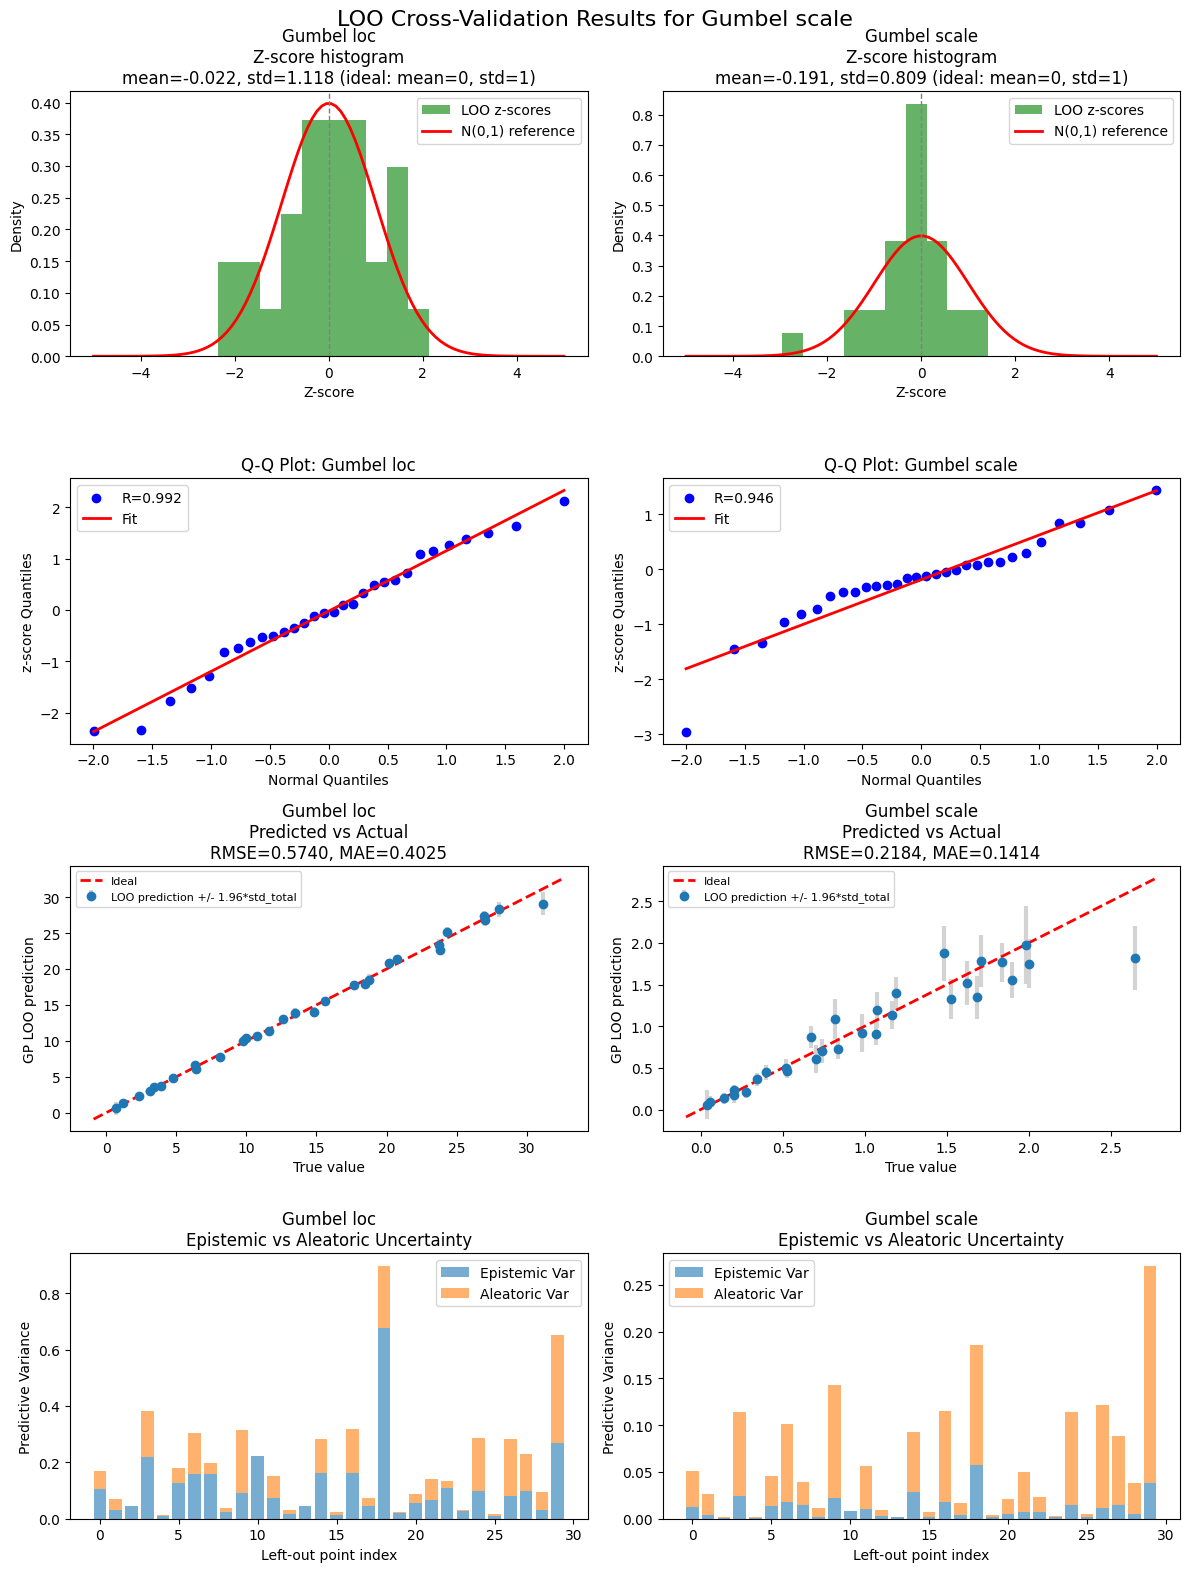


LOO results plot saved to results\GP_eval_results\loo_results_30_points.png


In [50]:
# Key metrics per output metric (loc and scale):
# 1. RMSE of predicted mean vs true value at left-out point.
# 2. Z-score = (y_pred_mean - y_left_out) / sqrt(pred_var_total)
#    - should be ~ N(0, 1) if uncertainties are well calibrated.
#    - Var[z] > 1: predictive variance too small, GP is overconfident.
#    - Var[z] < 1: predictive variance too large, GP is underconfident.
# 3. 95% CI coverage: fraction of held-out points where true value falls inside
#    [mu ± 1.96*sigma]. Should be close to 0.95.
# 4. Epistemic vs aleatoric split:
#    - High epistemic at a point -> more training data nearby would help.
#    - High aleatoric -> need more simulations per point to reduce label noise.

print("\nSTEP 6: Computing LOO metrics...")
loo_metrics_list = [compute_metrics(loo_results, metric_idx=i, metric_name=mn) for i, mn in enumerate(METRIC_NAMES)]

print_summary(loo_metrics_list)

print("\nSTEP 7: Plotting LOO results...")
fig = plot_loo_results(loo_results, loo_metrics_list, METRIC_DISPLAY_NAMES)
plt.show()

# save plots
results_dir = Path("results/GP_eval_results")
results_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(results_dir / f"loo_results_{N_TRAINING_POINTS}_points.png")
print(f"\nLOO results plot saved to {results_dir / f'loo_results_{N_TRAINING_POINTS}_points.png'}")
